trying to analyze EDM training loss over tick count

In [2]:
import os, json, matplotlib.pyplot as plt, numpy as np, tqdm
# %matplotlib widget

In [3]:
base_path = '/csiNAS3/yarefeen/PowerofPrior/trained-models/fastmri_brain_white_standardsize_192x192_v0'
experiment='00000-train-uncond-ddpmpp-edm-gpus4-batch60-fp32-fastmri_brain_white_standardsize_192x192_v0'
stats_path = os.path.join(base_path,experiment,'stats.jsonl')
print(stats_path)

/csiNAS3/yarefeen/PowerofPrior/trained-models/fastmri_brain_white_standardsize_192x192_v0/00000-train-uncond-ddpmpp-edm-gpus4-batch60-fp32-fastmri_brain_white_standardsize_192x192_v0/stats.jsonl


In [4]:
# Initialize a list to store the parsed JSON objects
data_list = []

# Open the file and read it line by line
with open(stats_path, 'r') as file:
    for line in tqdm.tqdm(file):
        # Parse the JSON object from the line and append it to the list
        json_obj = json.loads(line.strip())
        data_list.append(json_obj)
        
losses = []
for data in data_list:
    losses.append(data['Loss/loss']['mean'])
    
losses = np.array(losses)

3142it [00:00, 32477.05it/s]


(3142,)


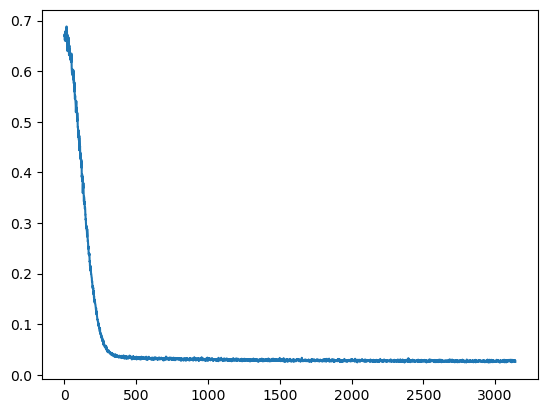

In [5]:
print(losses.shape)
plt.figure()
plt.plot(losses)
plt.show()

#### plotting losses at just the ticks which are saved

In [7]:
ticks_per_save = 25

snapshots = [f for f in os.listdir(os.path.join(base_path,experiment)) if f.startswith('network')]
snapshots = sorted(snapshots, key=lambda x:int(x[-10:-4]))
snapshots = [int(snapshot[-10:-4]) for snapshot in snapshots]
losses_save = losses[::ticks_per_save]

print(f'len losses save: {len(losses_save)}')
print(f'minimum index: {np.argmin(losses_save)}')
print(f'minimum net: {snapshots[np.argmin(losses_save)]}')
print(f'min loss: {np.min(losses_save):5f}')
plt.figure()
plt.plot(snapshots[:len(losses_save)],losses_save)
plt.show()


ValueError: invalid literal for int() with base 10: 'iorsam'